# NFL Kaggle Data 2026: Exploratory Data Analysis

## Introduction

We explore the NFL Big Data 2026 dataset: we summarize shape, distributions, and relationships using plots and summary statistics (EDA) before modeling.

We import dependencies and use seaborn. **All available weeks** under `train/` are loaded for both **output** and **input** (`output_2023_w*.csv` and `input_2023_w*.csv`). After each major figure bundle, a short note in plain English states what the plot shows and what that implies—including whether the pattern matches what you would expect from tracking data.


In [ ]:
import glob
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


We load every `output_2023_w*.csv` and `input_2023_w*.csv` under `TRAIN_DIR`, each with a **`week`** column. **Both** file types are required (same as in the training setup).


In [ ]:
TRAIN_DIR = "train"


def _week_from_path(p):
    m = re.search(r"w(\d+)", os.path.basename(p))
    return int(m.group(1)) if m else 0


_out_paths = sorted(glob.glob(os.path.join(TRAIN_DIR, "output_2023_w*.csv")))
if not _out_paths:
    raise FileNotFoundError("No output_2023_w*.csv files in %r" % TRAIN_DIR)

_df_out_parts = []
for p in _out_paths:
    w = _week_from_path(p)
    chunk = pd.read_csv(p)
    chunk["week"] = w
    _df_out_parts.append(chunk)
df_out = pd.concat(_df_out_parts, ignore_index=True)

_in_paths = sorted(glob.glob(os.path.join(TRAIN_DIR, "input_2023_w*.csv")))
if not _in_paths:
    raise FileNotFoundError(
        "Required: input_2023_w*.csv files in %r (next to output files)." % TRAIN_DIR
    )

_df_in_parts = []
for p in _in_paths:
    w = _week_from_path(p)
    chunk = pd.read_csv(p)
    chunk["week"] = w
    _df_in_parts.append(chunk)
df = pd.concat(_df_in_parts, ignore_index=True)

print(
    "Output rows: %s | weeks: %s"
    % (f"{len(df_out):,}", sorted(df_out["week"].unique().tolist()))
)
print("Input rows: %s" % f"{len(df):,}")


Output rows: 562,936 | weeks: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
Input rows: 4,880,579


### Output data: trajectory steps and spatial coverage (all weeks)

We use only the tracking output: per (game, play, player) trajectory we compute frame-to-frame steps and total path length, and a 2D density of positions.


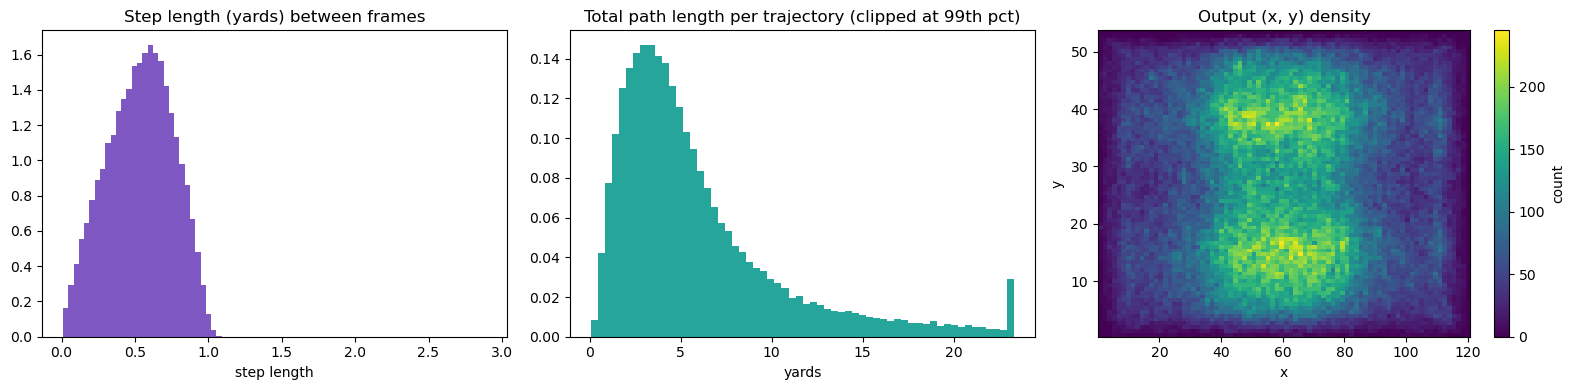

Step length: mean=0.5351, median=0.5464 (yards)
Path length: mean=6.0057, median=4.5918


In [ ]:
d_out = df_out.sort_values(["game_id", "play_id", "nfl_id", "frame_id"]).copy()
gkeys = ["game_id", "play_id", "nfl_id"]
d_out["dx"] = d_out.groupby(gkeys)["x"].diff()
d_out["dy"] = d_out.groupby(gkeys)["y"].diff()
d_out["step_len"] = np.sqrt(d_out["dx"] ** 2 + d_out["dy"] ** 2)

step_clean = d_out["step_len"].replace(0, np.nan).dropna()
traj_len = d_out.groupby(gkeys)["step_len"].sum().rename("path_length_yards")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(step_clean, bins=80, color="#7e57c2", edgecolor="none", density=True)
axes[0].set_title("Step length (yards) between frames")
axes[0].set_xlabel("step length")

clip_hi = traj_len.quantile(0.99)
axes[1].hist(traj_len.clip(upper=clip_hi), bins=60, color="#26a69a", edgecolor="none", density=True)
axes[1].set_title("Total path length per trajectory (clipped at 99th pct)")
axes[1].set_xlabel("yards")

sample_xy = d_out[["x", "y"]].dropna()
if len(sample_xy) > 500_000:
    sample_xy = sample_xy.sample(500_000, random_state=42)
h = axes[2].hist2d(sample_xy["x"], sample_xy["y"], bins=80, cmap="viridis")
axes[2].set_title("Output (x, y) density")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
plt.colorbar(h[3], ax=axes[2], label="count")
plt.tight_layout()
plt.show()

print("Step length: mean=%.4f, median=%.4f (yards)" % (step_clean.mean(), step_clean.median()))
print("Path length: mean=%.4f, median=%.4f" % (traj_len.mean(), traj_len.median()))


In the step-length histogram you see a sharp peak near half a yard and almost no mass on very large jumps, which is what you expect when positions are updated every frame at NFL tracking resolution; the path-length histogram is right-skewed with a long tail from longer routes, and clipping at the 99th percentile only trims a few extreme traces so the plot stays readable; the 2D (x,y) density then shows where output coordinates pile up on the field, which you can compare later to input-only maps to see how predicted motion shifts the cloud.


### Week-over-week stability (output)

Means and spreads of `x` and `y` by week help spot distribution shift across the season.


,x_mean,x_std,y_mean,y_std
week,,,,
1,59.0203,25.5501,26.5302,13.2496
2,61.3664,25.7830,26.5199,13.5582
3,59.4308,25.1476,25.9502,13.5777
4,61.6841,24.5985,27.3071,13.5969
5,62.0364,25.3007,26.4515,13.3207
6,60.7629,24.9839,26.0034,13.2765
7,59.3062,24.9033,27.3203,13.4137
8,61.9436,25.9910,27.6529,13.3364
9,61.3951,25.3852,27.1152,13.7031


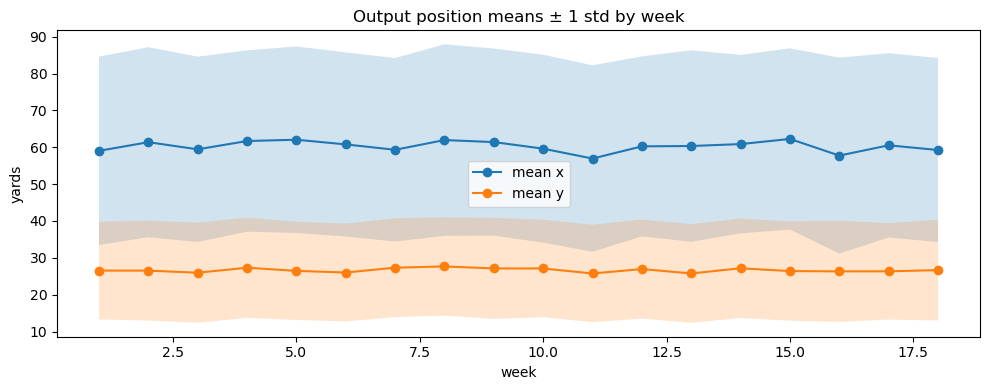

In [ ]:
wstats = df_out.groupby("week").agg(
    x_mean=("x", "mean"),
    x_std=("x", "std"),
    y_mean=("y", "mean"),
    y_std=("y", "std"),
).sort_index()

display(wstats.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
weeks = wstats.index.astype(int)
ax.plot(weeks, wstats["x_mean"], marker="o", label="mean x")
ax.fill_between(
    weeks,
    wstats["x_mean"] - wstats["x_std"],
    wstats["x_mean"] + wstats["x_std"],
    alpha=0.2,
)
ax.plot(weeks, wstats["y_mean"], marker="o", label="mean y")
ax.fill_between(
    weeks,
    wstats["y_mean"] - wstats["y_std"],
    wstats["y_mean"] + wstats["y_std"],
    alpha=0.2,
)
ax.set_xlabel("week")
ax.set_ylabel("yards")
ax.legend()
ax.set_title("Output position means ± 1 std by week")
plt.tight_layout()
plt.show()


The weekly mean lines for x and y with shaded bands show whether average positions drift through the season or stay stable: roughly flat trends mean pooling weeks is reasonable, while clear wiggles suggest week-specific shifts you may want to model or stratify; when the band is wider along x than y, that usually means more spread downfield than across the width, which is a common shape for these plays.


### Input: marginals (skew/kurtosis, KDE, categoricals)

Numeric summaries and plots per variable and per category in the **input** data.


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
x,4880579.0,60.5007,23.4892,0.41,42.63,60.41,78.23,119.86,0.0130,-0.6686
y,4880579.0,26.8119,10.0062,0.62,18.99,26.85,34.62,52.88,-0.0047,-0.7901
s,4880579.0,3.0199,2.2279,0.00,1.09,2.72,4.62,12.53,0.4896,-0.6984
a,4880579.0,2.1183,1.4158,0.00,1.01,1.92,3.04,17.12,0.6360,0.0326
absolute_yardline_number,4880579.0,60.5505,23.0594,11.00,41.00,61.00,80.00,109.00,-0.0012,-0.9323
ball_land_x,4880579.0,60.5158,25.2964,-5.26,42.61,60.51,78.47,125.85,0.0091,-0.4344
ball_land_y,4880579.0,26.6377,15.4381,-3.91,13.30,26.47,39.87,57.33,0.0090,-1.2267


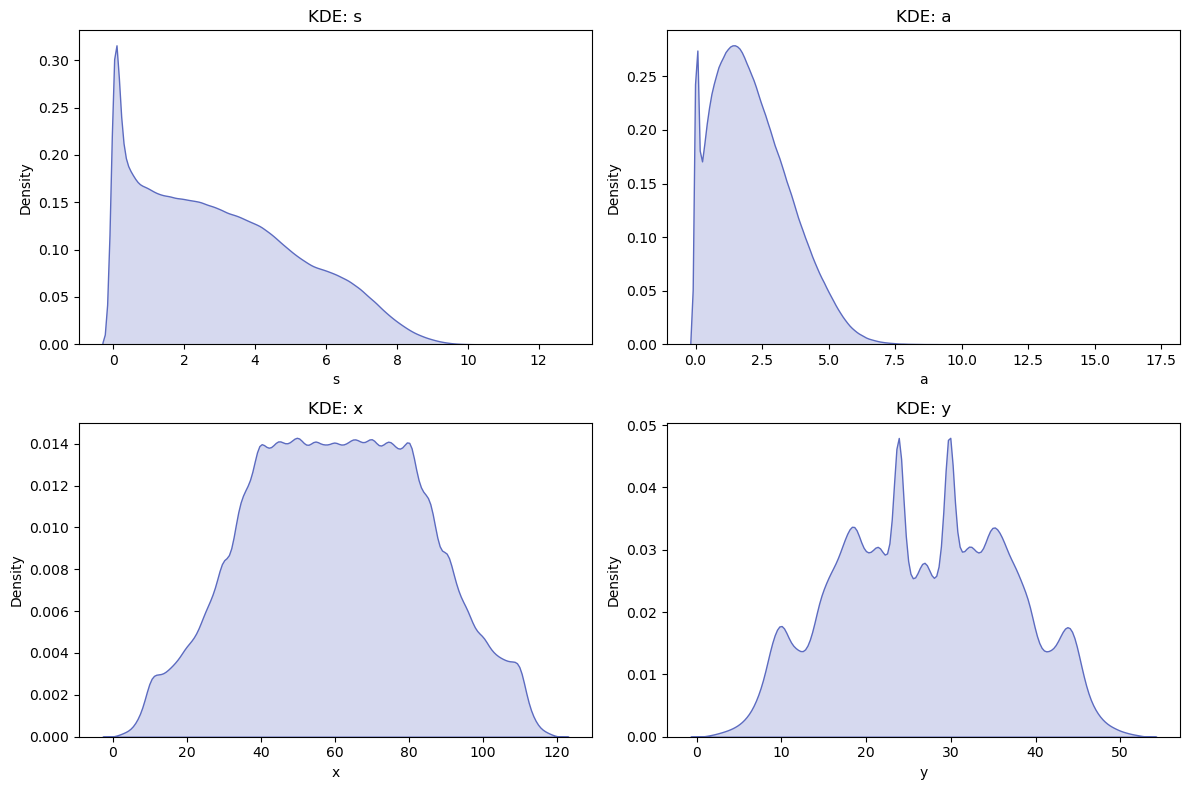

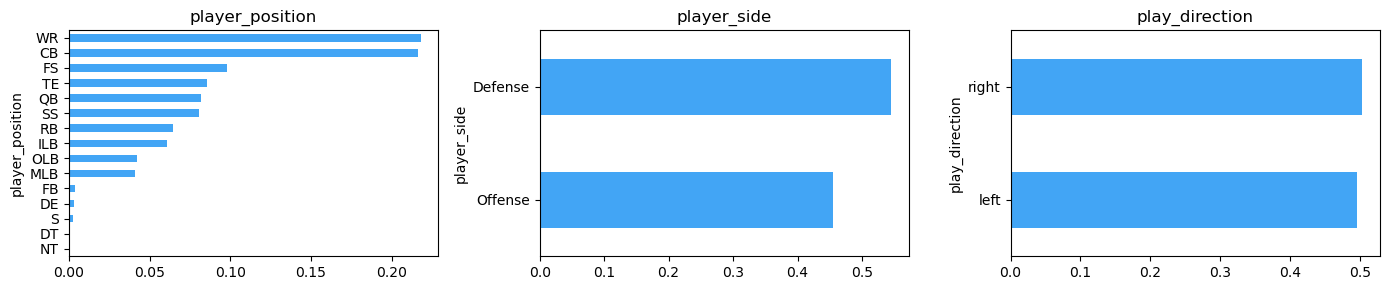

In [ ]:
num_cols = [
    c
    for c in [
        "x",
        "y",
        "s",
        "a",
        "absolute_yardline_number",
        "ball_land_x",
        "ball_land_y",
    ]
    if c in df.columns
]
desc = df[num_cols].describe().T
desc["skew"] = df[num_cols].skew()
desc["kurtosis"] = df[num_cols].kurtosis()
display(desc.round(4))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ["s", "a", "x", "y"]):
    if col not in df.columns:
        continue
    sns.kdeplot(df[col].dropna(), ax=ax, fill=True, color="#5c6bc0")
    ax.set_title("KDE: %s" % col)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, col in zip(axes, ["player_position", "player_side", "play_direction"]):
    if col not in df.columns:
        continue
    vc = df[col].astype(str).value_counts(normalize=True).head(15)
    vc.sort_values().plot(kind="barh", ax=ax, color="#42a5f5")
    ax.set_title(col)
plt.tight_layout()
plt.show()


The table with skew and kurtosis flags heavy-tailed variables (speed is a usual example); the KDEs show the expected pile-up at low speed and acceleration and often a twin-peaked lateral position pattern near the hashes, while the categorical bars show how often each role and play side appears—imbalance there is normal from how offenses are called but matters if you weight or split by group before training.


### Input-output continuity: last input frame vs first output frame

Distribution of delta x and delta y between the last input position and the first predicted output position (inner join on game, play, player).


Matched trajectories: 46045


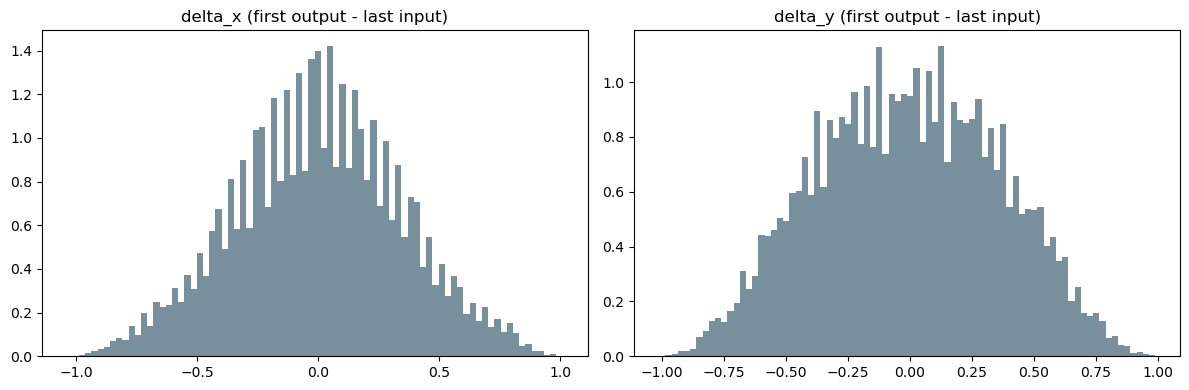

delta_x mean=0.0020 std=0.3430
delta_y mean=-0.0043 std=0.3664


In [ ]:
last_in = (
    df.sort_values(["game_id", "play_id", "nfl_id", "frame_id"])
    .groupby(["game_id", "play_id", "nfl_id"], as_index=False)
    .last()
)
first_out = (
    df_out.sort_values(["game_id", "play_id", "nfl_id", "frame_id"])
    .groupby(["game_id", "play_id", "nfl_id"], as_index=False)
    .first()
)
bridge = last_in[["game_id", "play_id", "nfl_id", "x", "y"]].merge(
    first_out[["game_id", "play_id", "nfl_id", "x", "y"]],
    on=["game_id", "play_id", "nfl_id"],
    suffixes=("_last_in", "_first_out"),
)
bridge["delta_x"] = bridge["x_first_out"] - bridge["x_last_in"]
bridge["delta_y"] = bridge["y_first_out"] - bridge["y_last_in"]
print("Matched trajectories:", len(bridge))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(bridge["delta_x"], bins=80, color="#78909c", edgecolor="none", density=True)
axes[0].set_title("delta_x (first output - last input)")
axes[1].hist(bridge["delta_y"], bins=80, color="#78909c", edgecolor="none", density=True)
axes[1].set_title("delta_y (first output - last input)")
plt.tight_layout()
plt.show()
print(
    "delta_x mean=%.4f std=%.4f"
    % (bridge["delta_x"].mean(), bridge["delta_x"].std())
)
print(
    "delta_y mean=%.4f std=%.4f"
    % (bridge["delta_y"].mean(), bridge["delta_y"].std())
)


You see delta_x and delta_y concentrated at zero, which means the first output frame usually continues smoothly from the last input frame and that is what you want from the input–output join; a comb-like pattern on delta_x often reflects discrete rounding on that axis rather than physics, so it is worth remembering when interpreting yard-level errors.


### Bivariate KDE (input): (s, a) and (x, y)

Joint density plots (subsampled for speed) complement the univariate KDEs above.

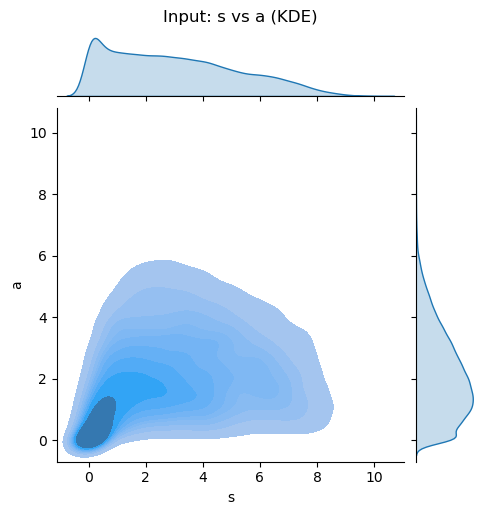

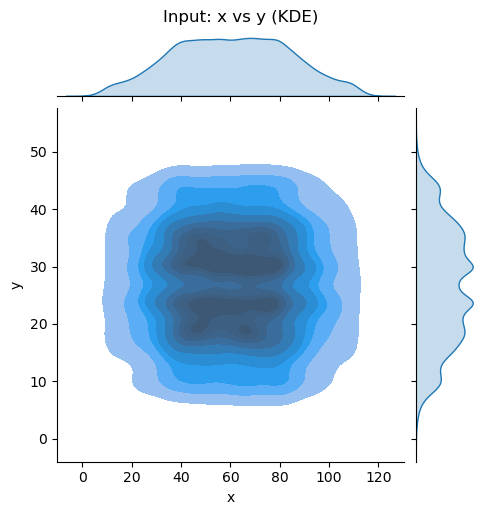

In [ ]:
n = min(50_000, len(df))
sub = df.sample(n, random_state=42) if len(df) > n else df
g1 = sns.jointplot(data=sub, x="s", y="a", kind="kde", fill=True, height=5)
g1.fig.suptitle("Input: s vs a (KDE)", y=1.02)
plt.show()
g2 = sns.jointplot(data=sub, x="x", y="y", kind="kde", fill=True, height=5)
g2.fig.suptitle("Input: x vs y (KDE)", y=1.02)
plt.show()


The speed–acceleration joint density piles up near the origin because most frames are slow with mild acceleration, which is expected between plays; the joint (x,y) view shows where players stand before the throw, with ridges that line up with hashes and typical alignments—again consistent with pre-pass snapshots rather than end-of-route chaos.


### Spatial density: last input frame vs output positions

Side-by-side `hist2d` of (x, y): one panel uses the **last** input frame per trajectory; the other uses **all** output rows (subsampled if large).

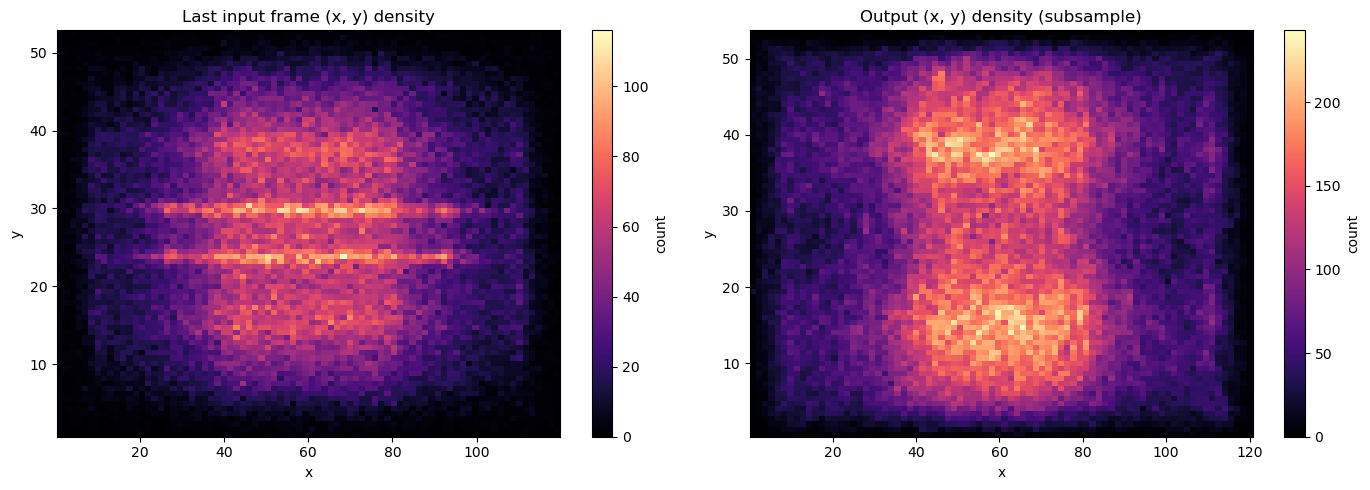

In [ ]:
gkeys = ["game_id", "play_id", "nfl_id"]
last_in_xy = (
    df.sort_values(gkeys + ["frame_id"])
    .groupby(gkeys, as_index=False)
    .last()[["x", "y"]]
)
out_xy = df_out[["x", "y"]].dropna()
if len(out_xy) > 500_000:
    out_xy = out_xy.sample(500_000, random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
h0 = axes[0].hist2d(last_in_xy["x"], last_in_xy["y"], bins=80, cmap="magma")
axes[0].set_title("Last input frame (x, y) density")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(h0[3], ax=axes[0], label="count")
h1 = axes[1].hist2d(out_xy["x"], out_xy["y"], bins=80, cmap="magma")
axes[1].set_title("Output (x, y) density (subsample)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(h1[3], ax=axes[1], label="count")
plt.tight_layout()
plt.show()


Side by side, the last-input heatmap still looks formation-structured (for example strong structure along y), while the output heatmap shifts toward where players move after the cutoff, so the mismatch is expected: freezing the last position cannot match the future distribution, and the pair of plots makes that gap obvious.


### Naive baseline: constant last-input prediction vs output track

If we predicted the **last input (x, y)** at every output frame, the Euclidean error at each output row shows a simple lower-bound reference for model error.

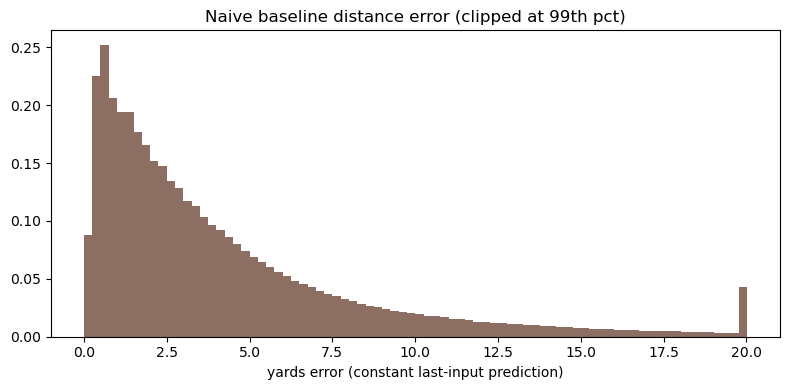

naive_dist mean=4.2467 median=2.8706 (yards)


In [ ]:
gkeys = ["game_id", "play_id", "nfl_id"]
last_in = (
    df.sort_values(gkeys + ["frame_id"])
    .groupby(gkeys, as_index=False)
    .last()[gkeys + ["x", "y"]]
    .rename(columns={"x": "lx", "y": "ly"})
)
out_m = df_out.merge(last_in, on=gkeys, how="inner")
out_m["naive_dist"] = np.sqrt((out_m["x"] - out_m["lx"]) ** 2 + (out_m["y"] - out_m["ly"]) ** 2)
plt.figure(figsize=(8, 4))
clip = out_m["naive_dist"].quantile(0.99)
plt.hist(out_m["naive_dist"].clip(upper=clip), bins=80, color="#8d6e63", edgecolor="none", density=True)
plt.xlabel("yards error (constant last-input prediction)")
plt.title("Naive baseline distance error (clipped at 99th pct)")
plt.tight_layout()
plt.show()
print(
    "naive_dist mean=%.4f median=%.4f (yards)"
    % (out_m["naive_dist"].mean(), out_m["naive_dist"].median())
)


When you measure error by repeating the last input position, the histogram shows most mass near zero because many short horizons barely move, with a tail for larger displacements; clipping the top keeps rare spikes from dominating the view—typical for this naive baseline, which only looks good when motion is almost static.


## General Data Overview

This section covers dtypes, correlation, frame counts, and a **feature inventory** (distributions and modeling notes) before the play-level factors below.


### Data shape and type

Here are the general information for the dataset. Shape of it, and datatypes of the columns. As mentioned in the dataset for 2023 week 1, there are 285714 recorded frames, and 23 columns. 

From kaggle, these are the meaning of each column :
- game_id: Game identifier, unique (numeric)
- play_id: Play identifier, not unique across games (numeric)
- player_to_predict: whether or not the x/y prediction for this player will be scored (bool)
- nfl_id: Player identification number, unique across players (numeric)
- frame_id: Frame identifier for each play/type, starting at 1 for each game_id/play_id/file type (input or output) (numeric)
- play_direction: Direction that the offense is moving (left or right)
- absolute_yardline_number: Distance from end zone for possession team (numeric)
- player_name: player name (text)
- player_height: player height (ft-in)
- player_weight: player weight (lbs)
- player_birth_date: birth date (yyyy-mm-dd)
- player_position: the player's position (the specific role on the field that they typically play)
- player_side: team player is on (Offense or Defense)
- player_role: role player has on play (Defensive Coverage, Targeted Receiver, Passer or Other Route Runner)
- x: Player position along the long axis of the field, generally within 0 - 120 yards. (numeric)
- y: Player position along the short axis of the field, generally within 0 - 53.3 yards. (numeric)
- s: Speed in yards/second (numeric)
- a: Acceleration in yards/second^2 (numeric)
- o: orientation of player (deg)
- dir: angle of player motion (deg)
- num_frames_output: Number of frames to predict in output data for the given game_id/play_id/nfl_id. (numeric)
- ball_land_x: Ball landing position position along the long axis of the field, generally within 0 - 120 yards. (numeric)
- ball_land_y: Ball landing position along the short axis of the field, generally within 0 - 53.3 yards. (numeric)

In [ ]:
print("General Info for Input Data:")
print("Data shape: ", df.shape)
print(df.dtypes)


General Info for Input Data:
Data shape:  (4880579, 24)
game_id                       int64
play_id                       int64
player_to_predict              bool
nfl_id                        int64
frame_id                      int64
play_direction               object
absolute_yardline_number      int64
player_name                  object
player_height                object
player_weight                 int64
player_birth_date            object
player_position              object
player_side                  object
player_role                  object
x                           float64
y                           float64
s                           float64
a                           float64
dir                         float64
o                           float64
num_frames_output             int64
ball_land_x                 float64
ball_land_y                 float64
week                          int64
dtype: object


### Feature Correlation

Upon doing research on exploratory data analysis, I have found that feature correlation graph could reveal helpful, hidden information. My research had showed that the quickest way to find feature correlation is by matching it in a matrix and calculating their similarity score.

I had done this by using a seaborn heatmap with red representing higher similarity scores. To calculate correlation (similarity) I had used the Pearson's correlation coefficient (in the code corr = df[features].corr() in which Pearson's is the default) :
$$r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2 \cdot \sum(y_i - \bar{y})^2}}$$

- Ranges from -1 (perfect negative) to +1 (perfect positive)
- Values near 0 indicate no linear relationship

From the result I had gotten, I had found that :
- x is closely correlated to absolute yardline number
- x is also closely correlated to ball_land_x

This phenomenon could easily be explained intuitively because the player's x location on the field's length wise will always be in line the ball landing's x position. Meanwhile, the fact that x is closely correlated to the absolute yardline number (the distance from the passer's team to the goal) could allow us to guess that most passes are towards the direction of the goal.

Furthermore, the fact that the y position of the player has less correlation to the y position of the ball landing could help us guess that most receivers spread laterally across the field rather than tracking directly to the ball's landing y position, suggesting routes are designed to create separation rather than mirror the ball's trajectory.

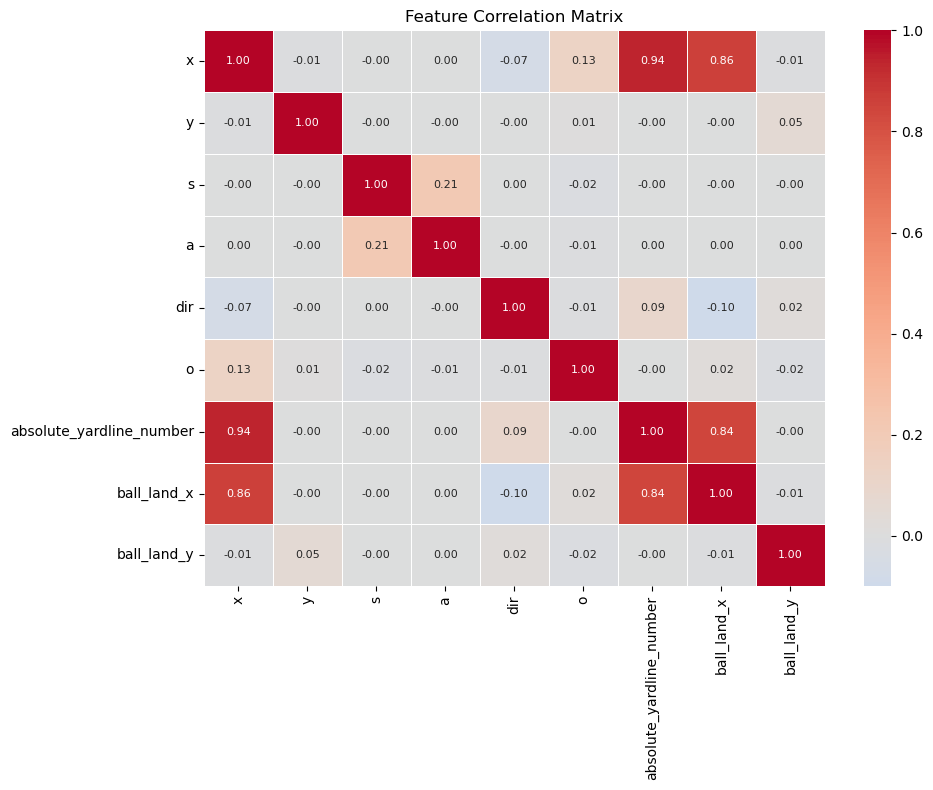

In [ ]:
features = ["x", "y", "s", "a", "dir", "o",
            "absolute_yardline_number", "ball_land_x", "ball_land_y"]
features = [f for f in features if f in df.columns]
corr = df[features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


The correlation matrix shows strong linear ties among x, yard line, and ball_land_x, which is expected because those all track lengthwise field position, while ties involving y and ball_land_y are weaker because routes do not have to finish on the same lateral line as the ball—that pattern helps spot redundant linear features and where non-linear terms might help.


### Data distribution 

Frames per player per play. This data is not generally very important, as it just shows what the average amount of data is recorded for each player per play. Of course, during each play, every player in that play has the same amount of recorded frames. 

As shown in this data, the must be at least 9 frames recorded, while at most 70+ frames per play. In average, there are 30 frames recorded per play.

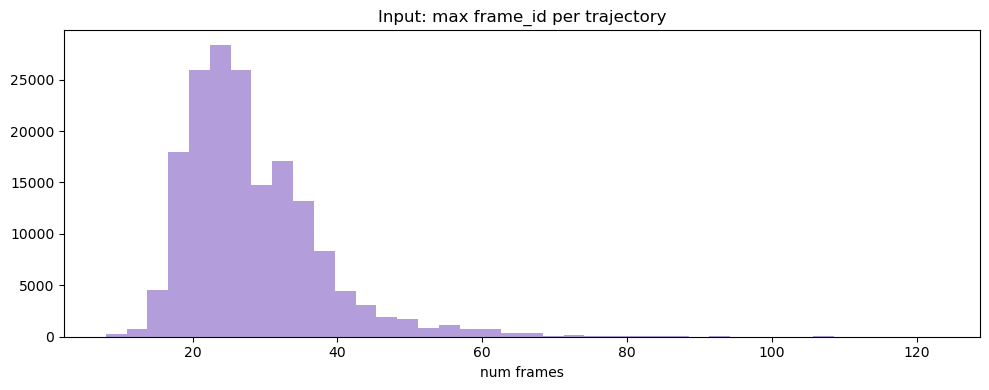

num_frames_output vs output max frame_id (should align):


,output_max - num_frames_output
count,46045.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


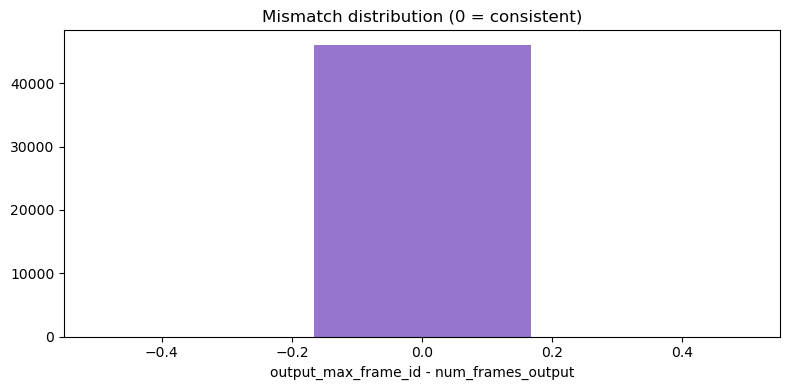

In [ ]:
gkeys = ["game_id", "play_id", "nfl_id"]
frames_per_play = df.groupby(gkeys)["frame_id"].max()
plt.figure(figsize=(10, 4))
plt.hist(frames_per_play, bins=40, color="#b39ddb", edgecolor="none")
plt.title("Input: max frame_id per trajectory")
plt.xlabel("num frames")
plt.tight_layout()
plt.show()
if "num_frames_output" in df.columns:
    reported = df.groupby(gkeys)["num_frames_output"].first()
    out_max = df_out.groupby(gkeys)["frame_id"].max()
    cmp = pd.DataFrame({"num_frames_output": reported, "output_max_frame_id": out_max}).dropna(how="any")
    cmp["diff"] = cmp["output_max_frame_id"] - cmp["num_frames_output"]
    print("num_frames_output vs output max frame_id (should align):")
    display(cmp["diff"].describe().to_frame("output_max - num_frames_output"))
    plt.figure(figsize=(8, 4))
    d = cmp["diff"].astype(int)
    bins = max(3, int(d.max() - d.min() + 1))
    plt.hist(d, bins=bins, color="#9575cd", edgecolor="none")
    plt.xlabel("output_max_frame_id - num_frames_output")
    plt.title("Mismatch distribution (0 = consistent)")
    plt.tight_layout()
    plt.show()


The max-frame histogram describes how long input observation clips are in the merged data; if the difference between max output frame_id and num_frames_output stacks at zero, that means the declared prediction horizon matches the files, whereas systematic offsets would point to a merge or labeling issue you should fix before building sequences.


### Feature inventory for modeling (input)

The cells below walk through the same idea in steps: first a per-column summary table, then histograms for heading, orientation, and yardline, then counts of categorical levels, then weight and the prediction flag, each followed by text that refers to the output you just ran.


In [ ]:
_id_cols = {"game_id", "play_id", "nfl_id", "frame_id"}


def _feature_table(d):
    rows = []
    for col in d.columns:
        if col == "week":
            continue
        s = d[col]
        miss = float(s.isna().mean() * 100)
        if pd.api.types.is_numeric_dtype(s) and col not in _id_cols:
            sk = float(pd.to_numeric(s, errors="coerce").skew()) if s.notna().any() else np.nan
            rows.append(
                {
                    "column": col,
                    "kind": "numeric",
                    "missing_pct": miss,
                    "n_unique": int(s.nunique()),
                    "skew": sk,
                }
            )
        elif col in _id_cols:
            rows.append(
                {
                    "column": col,
                    "kind": "id",
                    "missing_pct": miss,
                    "n_unique": int(s.nunique()),
                    "skew": np.nan,
                }
            )
        elif col == "player_name":
            rows.append(
                {
                    "column": col,
                    "kind": "text",
                    "missing_pct": miss,
                    "n_unique": int(s.nunique()),
                    "skew": np.nan,
                }
            )
        else:
            rows.append(
                {
                    "column": col,
                    "kind": "categorical",
                    "missing_pct": miss,
                    "n_unique": int(s.nunique()),
                    "skew": np.nan,
                }
            )
    return pd.DataFrame(rows).sort_values(["kind", "column"]).reset_index(drop=True)


display(_feature_table(df).round(3))


,column,kind,missing_pct,n_unique,skew
0,play_direction,categorical,0.0,2,NaN
1,player_birth_date,categorical,0.0,1132,NaN
2,player_height,categorical,0.0,16,NaN
3,player_position,categorical,0.0,19,NaN
4,player_role,categorical,0.0,4,NaN
5,player_side,categorical,0.0,2,NaN
6,frame_id,id,0.0,123,NaN
7,game_id,id,0.0,272,NaN
8,nfl_id,id,0.0,1384,NaN
9,play_id,id,0.0,4317,NaN


Each row matches one column in the table above. The `missing_pct` value is the share of missing values in that column—if it is high, you would impute, drop the column, or avoid using it as a feature. Where `skew` appears on numeric rows, values far from zero usually mean a skewed distribution with a long tail. The `kind` column tells you whether the field is treated as a numeric feature, an identifier, free text, or a categorical label, which matches how you would wire it into a model.


I plot histograms for `dir` (heading, degrees), `o` (orientation, degrees), and `absolute_yardline_number`, using at most 500,000 random rows so my notebook stays responsive.


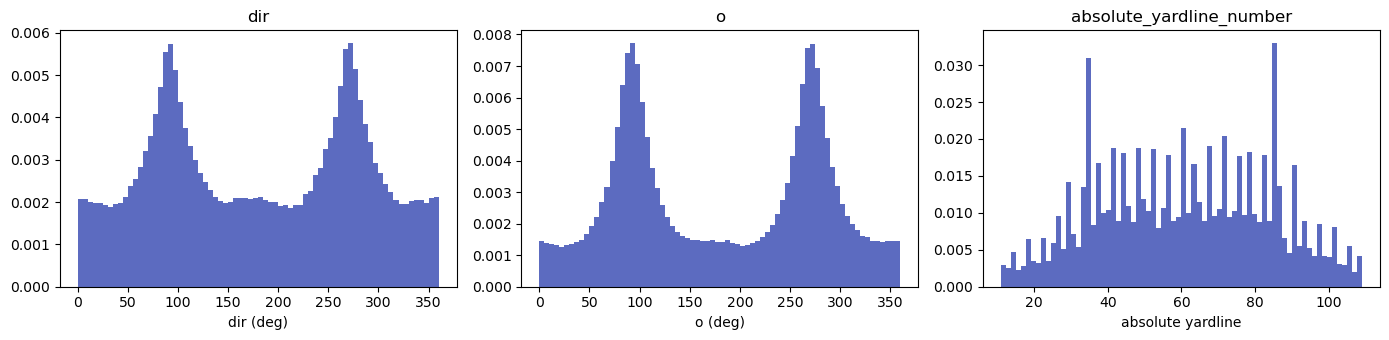

In [49]:
_sample = df if len(df) <= 500_000 else df.sample(500_000, random_state=42)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col, xlab in zip(
    axes,
    ["dir", "o", "absolute_yardline_number"],
    ["dir (deg)", "o (deg)", "absolute yardline"],
):
    v = _sample[col].dropna()
    ax.hist(v, bins=72, color="#5c6bc0", edgecolor="none", density=True)
    ax.set_title(col)
    ax.set_xlabel(xlab)
plt.tight_layout()
plt.show()


When we  see mass spread across the full range of angles for `dir` and `o`, which is what you expect when players face different ways on the field; those columns add facing information on top of `(x, y)`. The yardline histogram shows how often plays occur at different field positions; that line of information overlaps with downfield coordinates and ball landing, so in a simple linear model some predictors will look redundant even though a nonlinear model can still use all of them.


We print how many distinct labels appear in `play_direction`, `player_side`, `player_role`, and `player_position`, and plot a horizontal bar chart of those counts so can compare cardinality at a glance.


Levels per column:
  play_direction: 2
  player_side: 2
  player_role: 4
  player_position: 19


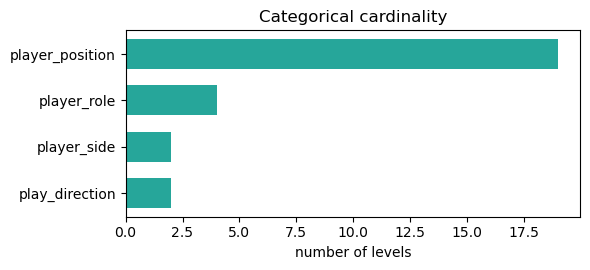

In [57]:
cat_cols = ["play_direction", "player_side", "player_role", "player_position"]
cat_cols = [c for c in cat_cols if c in df.columns]
print("Levels per column:")
for c in cat_cols:
    print("  %s: %d" % (c, df[c].nunique()))

card = pd.DataFrame({"column": cat_cols, "n_levels": [df[c].nunique() for c in cat_cols]}).sort_values(
    "n_levels"
)
plt.figure(figsize=(6, 2.8))
plt.barh(card["column"], card["n_levels"], color="#26a69a", height=0.65)
plt.xlabel("number of levels")
plt.title("Categorical cardinality")
plt.tight_layout()
plt.show()


From my printout and bars, direction and side only have a few levels, while role and especially position have more. I would one-hot the small fields; for the larger ones I am leaning toward embeddings or grouping if I need to cap parameters.


I use two panels here: a histogram of `player_weight` in pounds, and a bar chart of the row share where `player_to_predict` is true versus false.


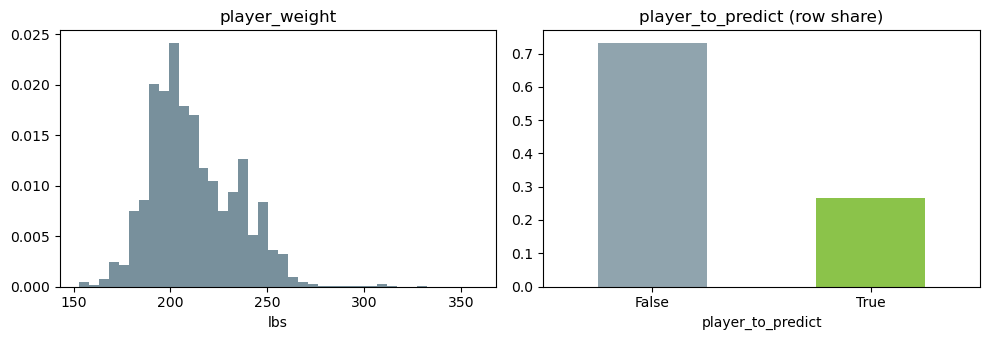

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
if "player_weight" in df.columns:
    axes[0].hist(df["player_weight"].dropna(), bins=40, color="#78909c", edgecolor="none", density=True)
    axes[0].set_title("player_weight")
    axes[0].set_xlabel("lbs")
if "player_to_predict" in df.columns:
    vc = df["player_to_predict"].value_counts(normalize=True)
    colors = ["#90a4ae", "#8bc34a"] if len(vc) == 2 else None
    vc.plot(kind="bar", ax=axes[1], color=colors)
    axes[1].set_title("player_to_predict (row share)")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()


We can see a reasonable spread of weights in the left panel. On the right, `player_to_predict` shows how imbalanced scored versus non-scored frames are, so we need to mirror that in  loss weighting or sampling if we want training to line up with the competition metric.


Overall, this block tells me which columns look complete, how the numeric distributions behave, how large each categorical is, and how weight and the scoring flag split. We will lean on that when  choosing inputs; the next sections add ball landing and role-level motion on top of this.


## Investigating Factors that affects our prediction (Key EDA)

### Ball landing distribution

Intuitively, attack receivers move towards the ball, while other attackers move depends on tactics. Defense will almost always move with attackers. Thus, if most of the ball landing distribution is on one area, model could be skewed.

We will generate the locations of wherever the ball lands. I wanted to how the ball landing is distributed generally and found that it is relatively spreadout with more plays in the middle. This is one of the most crucial factors that dictate where the players end up in our prediction. 

The distribution presents that data might be skewed to the middle for this week's dataset, if a model only uses this week.

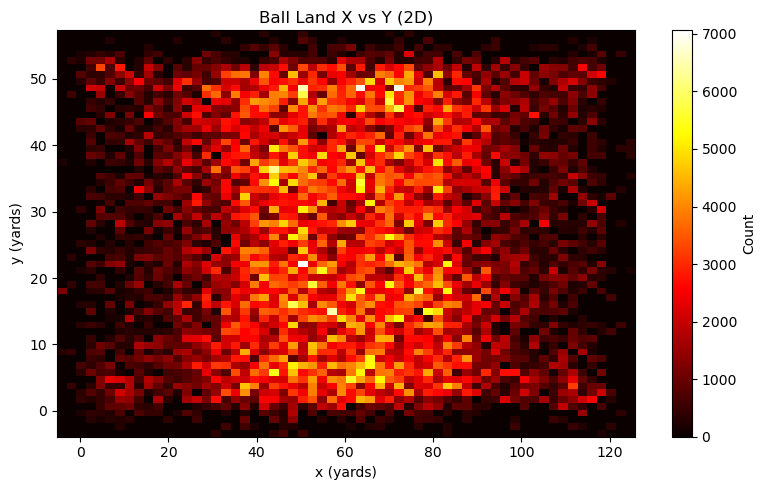

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist2d(
    df["ball_land_x"].dropna(), df["ball_land_y"].dropna(),
    bins=60, cmap="hot"
)
plt.colorbar(label="Count")
plt.title("Ball Land X vs Y (2D)")
plt.xlabel("x (yards)")
plt.ylabel("y (yards)")
plt.tight_layout()
plt.show()


Where ball_land_x and ball_land_y concentrate in the 2D view shows whether pass targets cluster in a tight part of the field or spread out—a tight cluster explains why a model might lean on a typical aim zone, while a broad spread reflects varied depths and directions that match diverse play calls.


### Player Roles

The next factor we could be considering in our player movement prediction is the player roles. Some player roles are filled by fast players, while others are filled by slow but strong players. Firstly, we want to count how many player's data is recorded based on player role. As we believe, one of the factors that affects the prediction is the player role.

This distribution describes that there are more data for defensive coverage roles than any other roles, with the passer's data being the least recorded. This makes sense, as once the ball is in the air only the information for the defensive coverage for the defense and the route runner with the receiver for the offense is important, as the passer is unlikely to be the one intercepting or receiving his own pass (while the ball is on the air). 

Moreover, there will be more information from the defensive coverage, as opposed to the receiver as there could be multiple people defending the pass as opposed to the 1 guy receiving it.

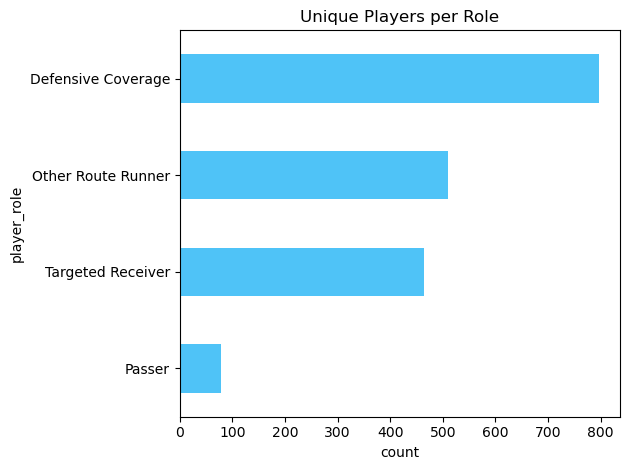

In [53]:
df.groupby("player_role")["nfl_id"].nunique().sort_values().plot(
    kind="barh", color="#4fc3f7"
)
plt.title("Unique Players per Role")
plt.xlabel("count")
plt.tight_layout()
plt.show()


The distinct-player counts by role show which positions are represented by many different athletes versus a thin roster, which explains where role summaries are statistically stable and where small samples could be noisy or driven by a few players.


In order to find speed and acceleration distirbution, taking the mean of the speed and acceleration throughout the data, for each game or even for each play would not be very efficient.Hence, if we could figure out speed and acceleration based on player roles, we could discern how much player roles affect, how far player moves.

The distribution showed us that the targeted receiver and the other route runner has the highest speed and acceleration in these scenarios, while the passer has the least. This allows us to conclude that when a pass is made, it is towards the direction of the defense (since they do not have to run as fast to get to the same location) meaning the defense will always be the closest to the absolute yard point. 

Furthermore, after the pass is made, it can be concluded that in the offense, the passer will not move as much, while the receiver and the other route runner will run the most while the ball is in the air. This allows our model to predict higher speed and acceleration for those two roles.

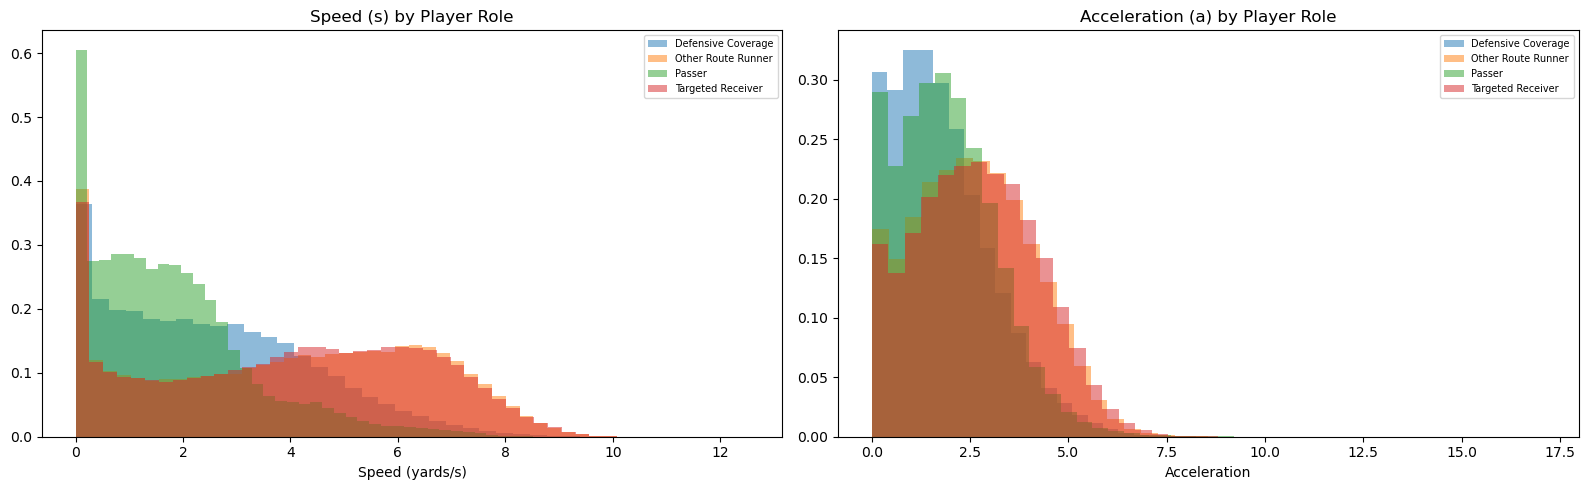

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for role, grp in df.groupby("player_role"):
    axes[0].hist(grp["s"].dropna(), bins=40, alpha=0.5, label=role, density=True)
    axes[1].hist(grp["a"].dropna(), bins=40, alpha=0.5, label=role, density=True)
axes[0].set_title("Speed (s) by Player Role")
axes[0].set_xlabel("Speed (yards/s)")
axes[0].legend(fontsize=7)
axes[1].set_title("Acceleration (a) by Player Role")
axes[1].set_xlabel("Acceleration")
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()


You see overlapping but separated speed and acceleration histograms by role, which is expected because jobs impose different movement patterns; that supports encoding role or evaluating metrics within role so one group does not dominate overall averages.


The third factor that could affect player movement prediction is their rate of turning, again based on role. 
Note that by taking the difference in speed per frame, we could determine the rate of turning.

In the delta speed graph, a +1 indicates a positive change in speed (gets faster) while a -1 is a deceleration, while in the delta direction graph a -40 indicates a 40 degree trun counterclockwise and +40 represents clockwise direction change.

In this plot, we could conclude that players do not turn much in their trajectory, and that the receiver accelerates the most.

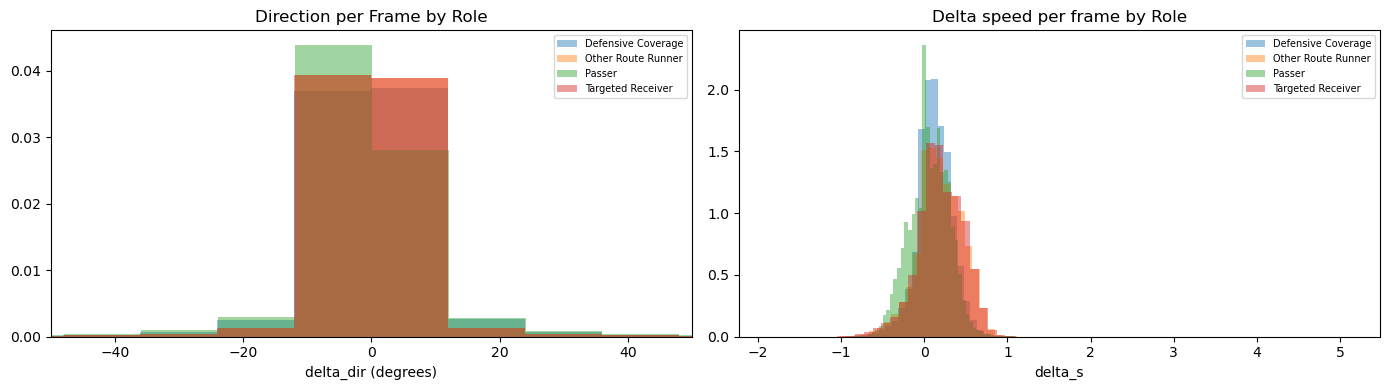

In [55]:
df = df.sort_values(["game_id", "play_id", "nfl_id", "frame_id"])
df["delta_dir"] = df.groupby(["game_id", "play_id", "nfl_id"])["dir"].diff()
df["delta_s"] = df.groupby(["game_id", "play_id", "nfl_id"])["s"].diff()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for role, grp in df.groupby("player_role"):
    axes[0].hist(grp["delta_dir"].dropna(), bins=60, alpha=0.45, label=role, density=True)
    axes[1].hist(grp["delta_s"].dropna(), bins=60, alpha=0.45, label=role, density=True)
axes[0].set_title("Direction per Frame by Role")
axes[0].set_xlabel("delta_dir (degrees)")
axes[0].set_xlim(-50, 50)
axes[0].legend(fontsize=7)
axes[1].set_title("Delta speed per frame by Role")
axes[1].set_xlabel("delta_s")
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()


Most per-frame changes in direction and speed sit near zero with heavier tails for occasional cuts or bursts, which matches smooth tracking with rare events—typical for this data—and hints whether features that emphasize turns or sudden speed changes could add signal.


Distance from ball alnding based on player role. This is arguably one of the more important distributions. Earlier, we had discerned that most players will be laterally at the same position (close x coordinate correlation to the ball landing), while this is not true for the y axis. 

THis distribution helps us discern how separated the roles are from each other, and allows the model to predict the positions of the players to be skewed towards this value. As expected, the tareted receiver has the least distance to the ball, while the defense coverage is the second closest to the ball. This means that more often than not the receiver catches the ball (when the distance from ball to receiver = 0).

The other route runner will be the furthest away from the ball to diffuse the defense.

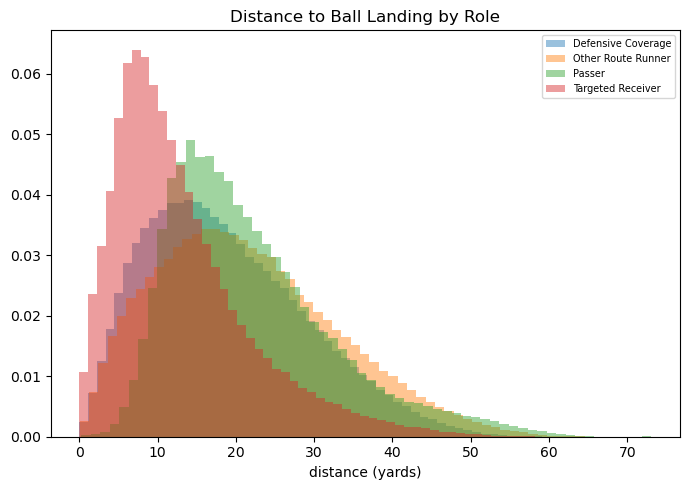

In [56]:
df["dist_to_ball_x"] = df["ball_land_x"] - df["x"]
df["dist_to_ball_y"] = df["ball_land_y"] - df["y"]
df["dist_to_ball"] = np.sqrt(df["dist_to_ball_x"] ** 2 + df["dist_to_ball_y"] ** 2)
fig, axes = plt.subplots(1, 1, figsize=(7, 5))
for role, grp in df.groupby("player_role"):
    axes.hist(grp["dist_to_ball"].dropna(), bins=60,
              alpha=0.45, label=role, density=True)
axes.set_title("Distance to Ball Landing by Role")
axes.set_xlabel("distance (yards)")
axes.legend(fontsize=7)
plt.tight_layout()
plt.show()


Distance to the ball landing location by role usually keeps targeted receivers closer to the ball than deep coverage players, which lines up with how routes develop and shows how demanding it is for each role to be near the landing spot at the last input frame.


## Insights

### Feature takeaways for training

- **Geometry and motion:** The model predicts **future** `(x, y)` on the output frames. As **inputs**, use the **observed history** from the input window: past positions `(x, y)` plus `s`, `a`, and optionally `dir` / `o` at those same past frames. Same column names, different time: history in, future positions out.
- **Field and play context:** `absolute_yardline_number`, `play_direction`, and `ball_land_x` / `ball_land_y` encode where the play happens and where the pass is aimed—useful for conditioning trajectory models; watch redundancy with `x` (correlation section).
- **Roles and who to predict:** `player_role`, `player_position`, `player_side` stratify movement; include them as categoricals or group-normalized targets. Filter or weight by `player_to_predict` so training matches the evaluation rows.
- **Player metadata:** `player_weight` (and height if parsed in preprocessing) can condition the same role differently; `player_name` is high-cardinality id—usually omit or map to `nfl_id`.

### What we can change for our models?

- Build **node / edge features** from the inventory above (kinematics + context + categoricals); reserve heavy coordinate standardization and graph construction for the preprocessing pipeline.
- Align **training objectives** with scoring: emphasize rows where `player_to_predict` is true and validate sequence windows against `num_frames_output` before fitting a sequence or GNN model.


## Conclusion

In conclusion, we will use player role and ball landing to predict. and we are using GNN.